# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
      confusion_matrix,
      ConfusionMatrixDisplay,
      accuracy_score,
      recall_score,
      precision_score,
      f1_score
)

from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RandomizedSearchCV


from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

# **Loading the dataset**

In [ ]:
file_path = './EasyVisa.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
print(df.shape)
print(df.describe())
df.head()

(25480, 12)
       no_of_employees   yr_of_estab  prevailing_wage
count     25480.000000  25480.000000     25480.000000
mean       5667.043210   1979.409929     74455.814592
std       22877.928848     42.366929     52815.942327
min         -26.000000   1800.000000         2.136700
25%        1022.000000   1976.000000     34015.480000
50%        2109.000000   1997.000000     70308.210000
75%        3504.000000   2005.000000    107735.512500
max      602069.000000   2016.000000    319210.270000


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Only two columns, no_of_employees and prevailing_wage seem to be scaled numerical values.

In [ ]:
df.isnull().sum()
# no null values in our data set


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [ ]:
# create our categorical and quantitative columns:
categorical_columns = ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training',
                       'region_of_employment', 'full_time_position', 'case_status', 'unit_of_wage']
quantitative_columns = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

# **Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)? *
2. How does the education level of employees impact visa approval rates? *
3. Is there a significant difference in visa approval rates between employees with and without prior job experience? *
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval? *
5. Do certain regions in the US have higher visa approval rates compared to others? *
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates? *


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

In [ ]:
# visa case status distribution
case_status_counts = df['case_status'].value_counts()/len(df)
print(case_status_counts)
# Certified    0.667896
# Denied       0.332104

case_status
Certified    0.667896
Denied       0.332104
Name: count, dtype: float64


In [ ]:
# value counts for all other categorical variables
for i in categorical_columns:
  if i == 'case_status':
    continue
  print(df[i].value_counts()/len(df))
  print("\n")

continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: count, dtype: float64


education_of_employee
Bachelor's     0.401648
Master's       0.378100
High School    0.134223
Doctorate      0.086028
Name: count, dtype: float64


has_job_experience
Y    0.580926
N    0.419074
Name: count, dtype: float64


requires_job_training
N    0.884027
Y    0.115973
Name: count, dtype: float64


region_of_employment
Northeast    0.282378
South        0.275392
West         0.258477
Midwest      0.169035
Island       0.014717
Name: count, dtype: float64


full_time_position
Y    0.89376
N    0.10624
Name: count, dtype: float64


unit_of_wage
Year     0.901177
Hour     0.084655
Week     0.010675
Month    0.003493
Name: count, dtype: float64




Unbalanced Data Observations:
- unit_of_wage seems extrememly unbalanced, with majority of data being "Year"
- continent is unbalanced with majority of data being "Asia"
- full_time_position has much more Y than N.
- requires_job_training has much more Y than N.

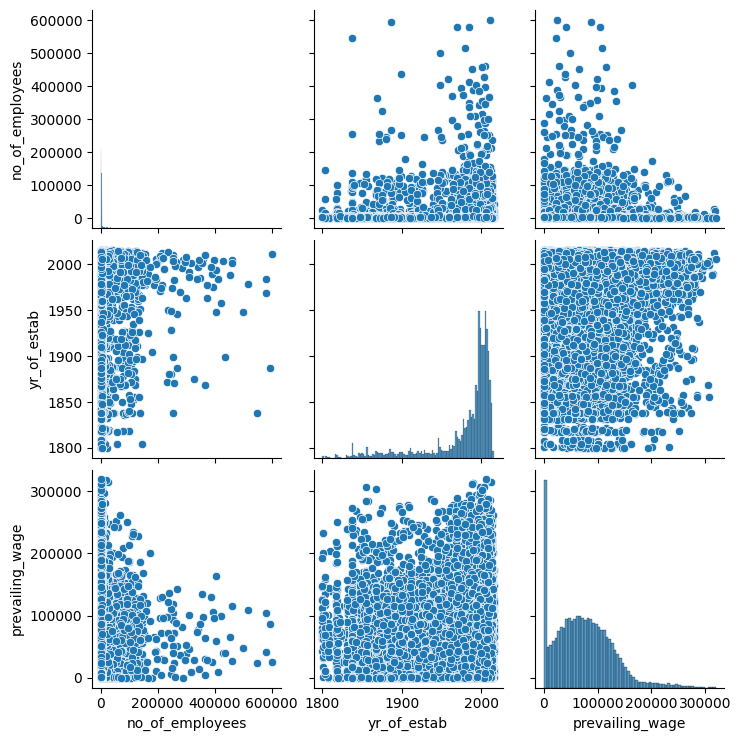

In [ ]:
# pair plot of quanititave data

sns.pairplot(df[quantitative_columns])
plt.show()

We cannot see any clear linear relationship between our quantitative data other than it seems we have many outliers

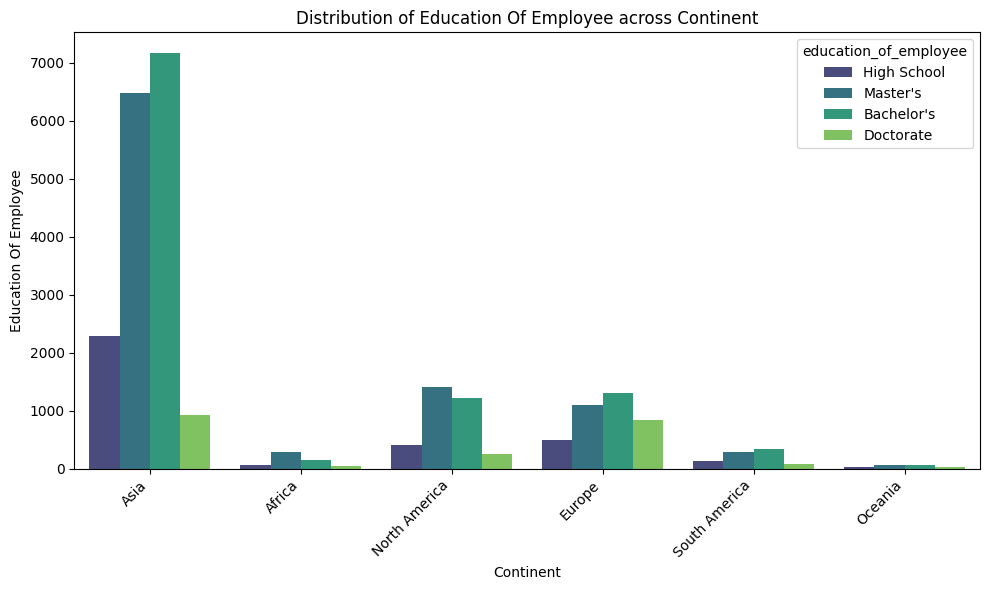

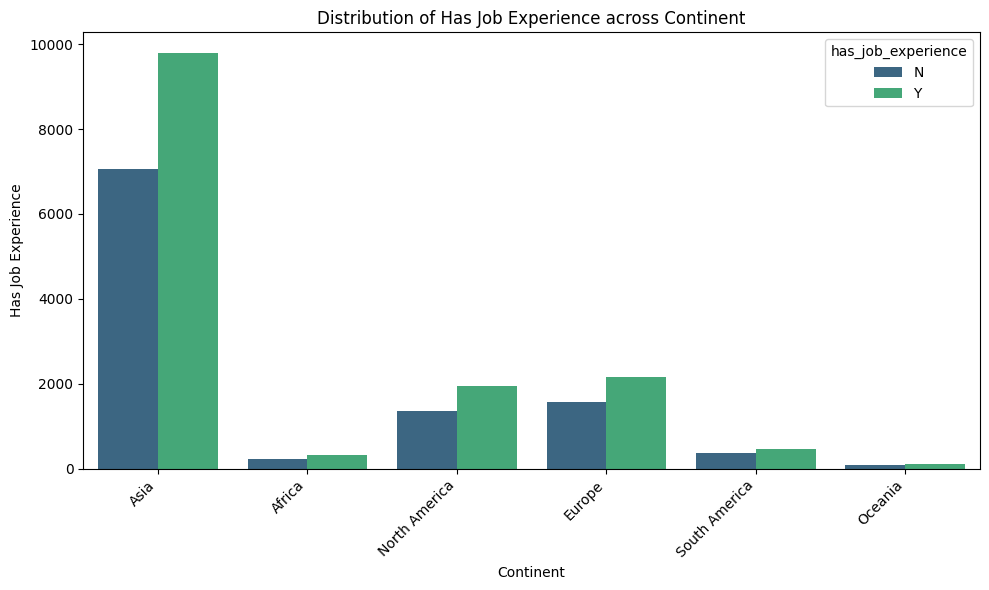

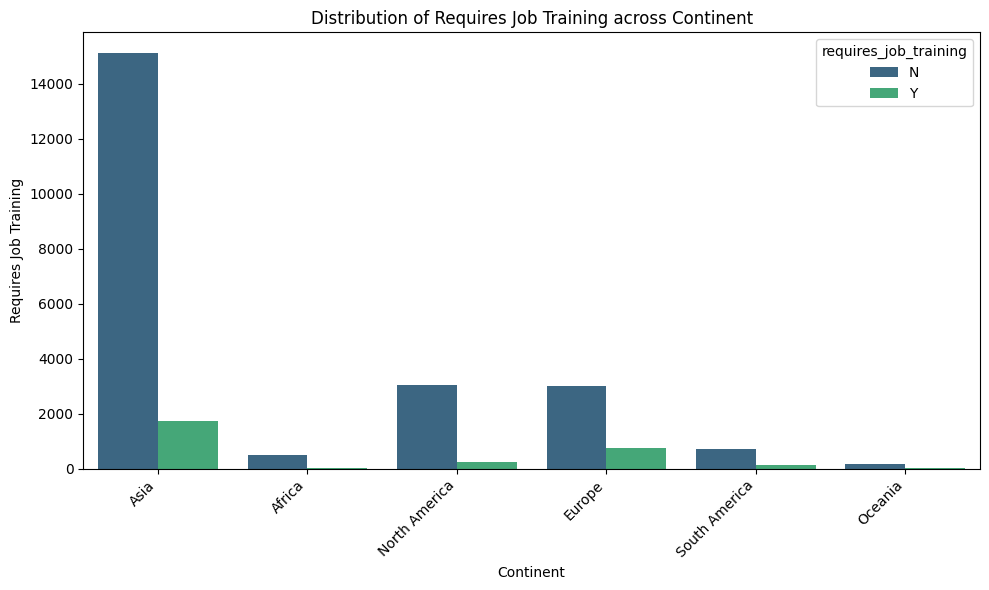

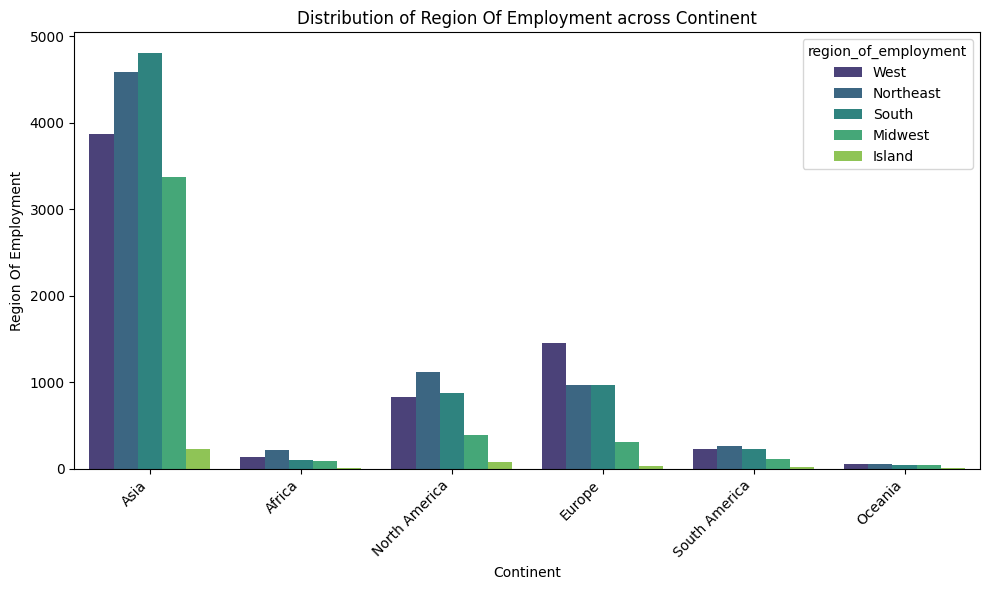

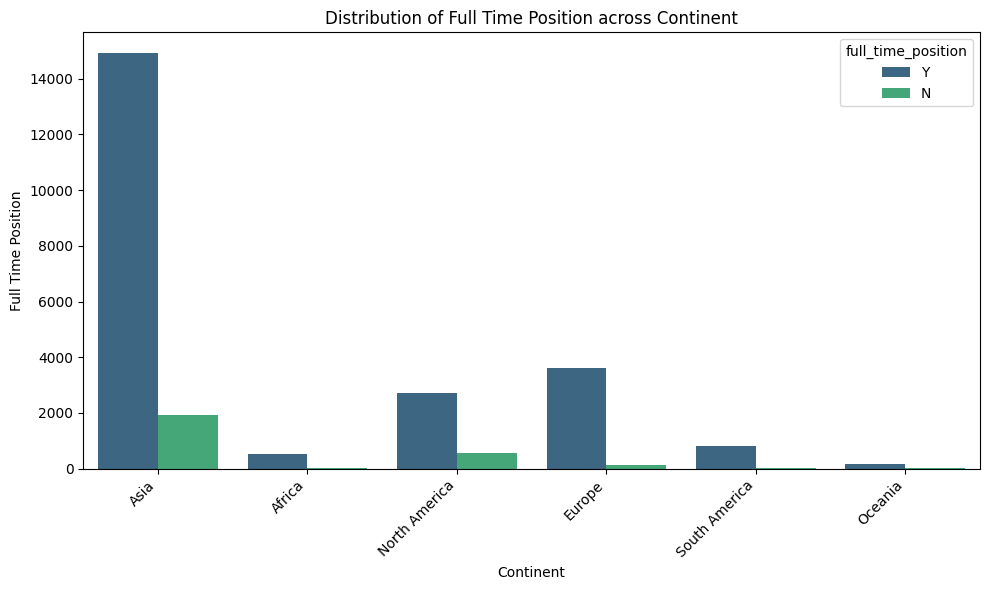

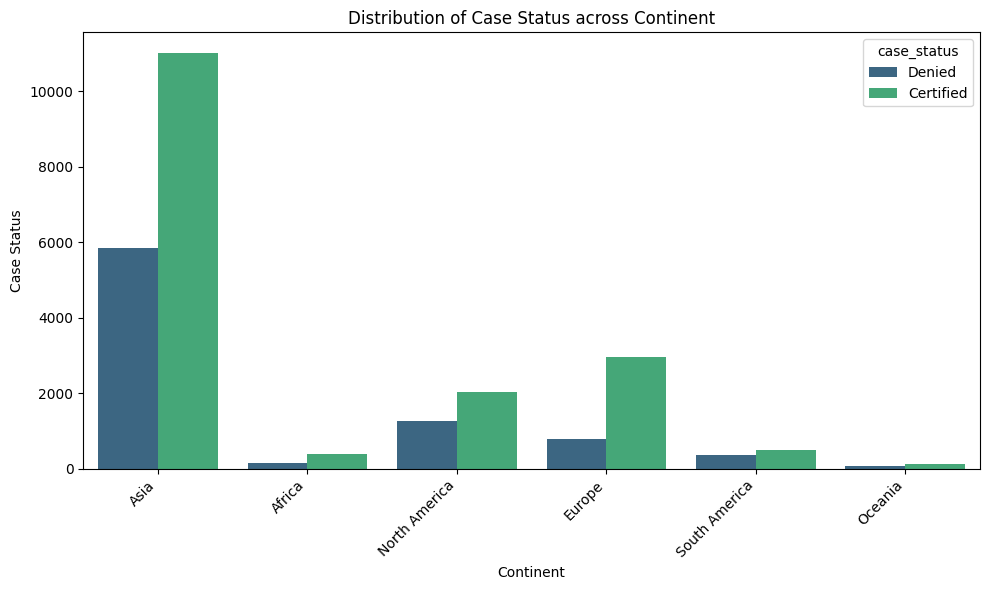

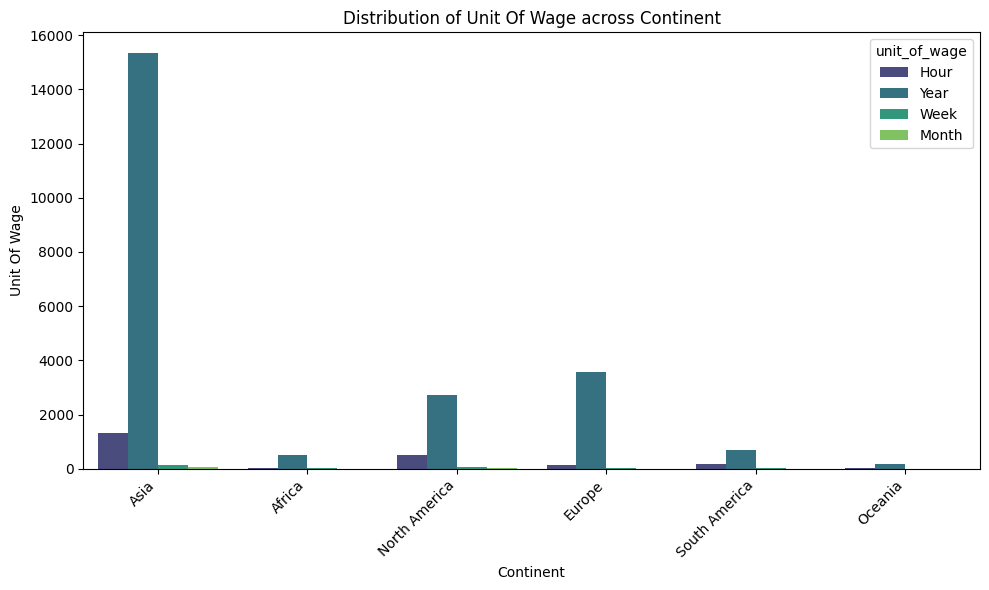

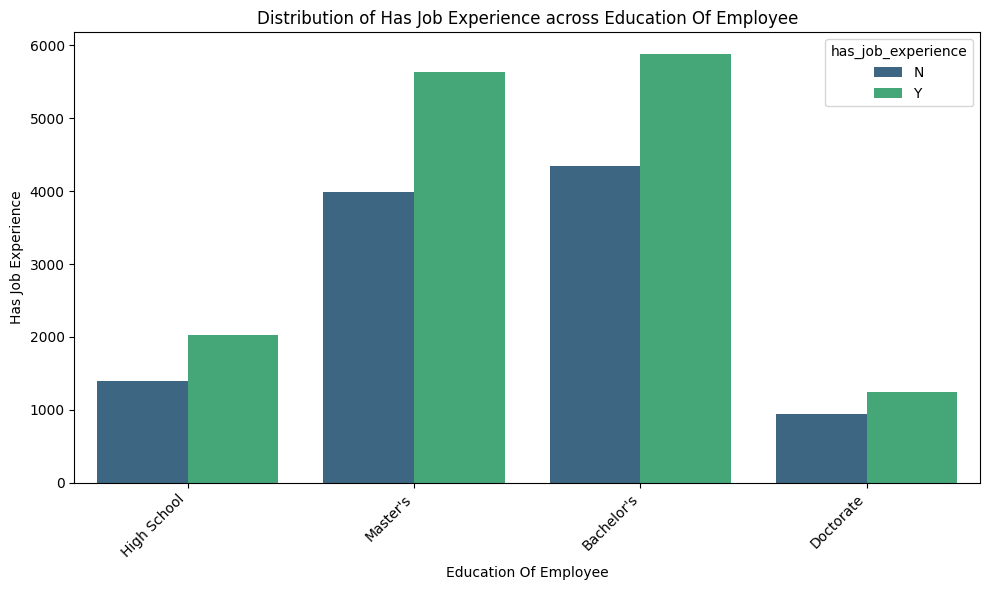

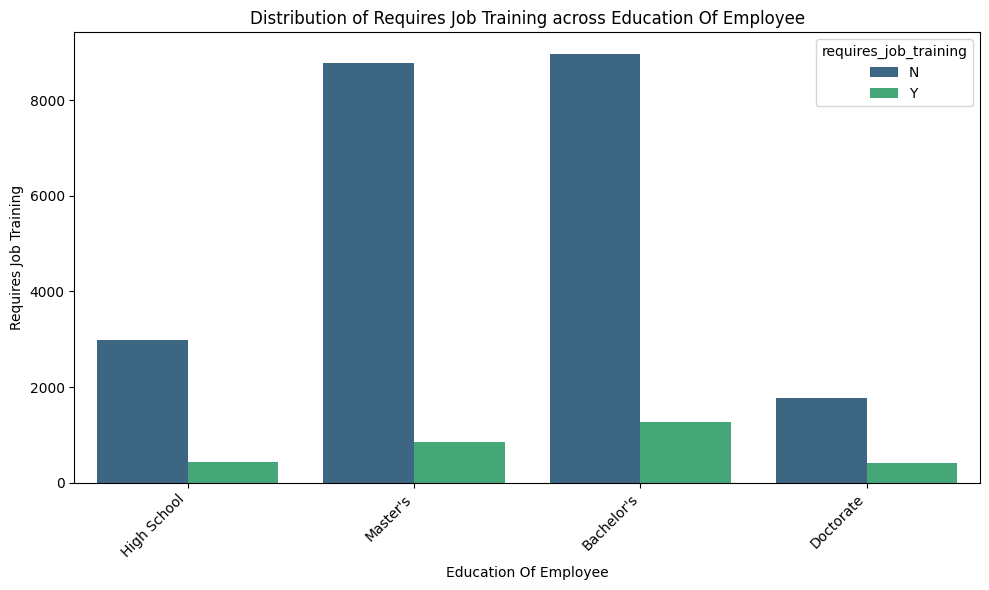

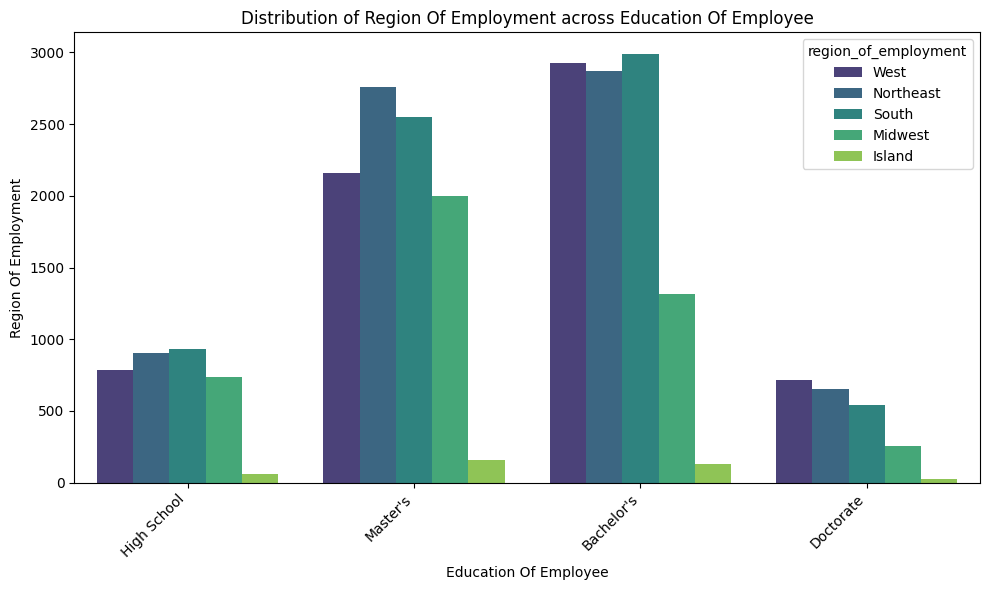

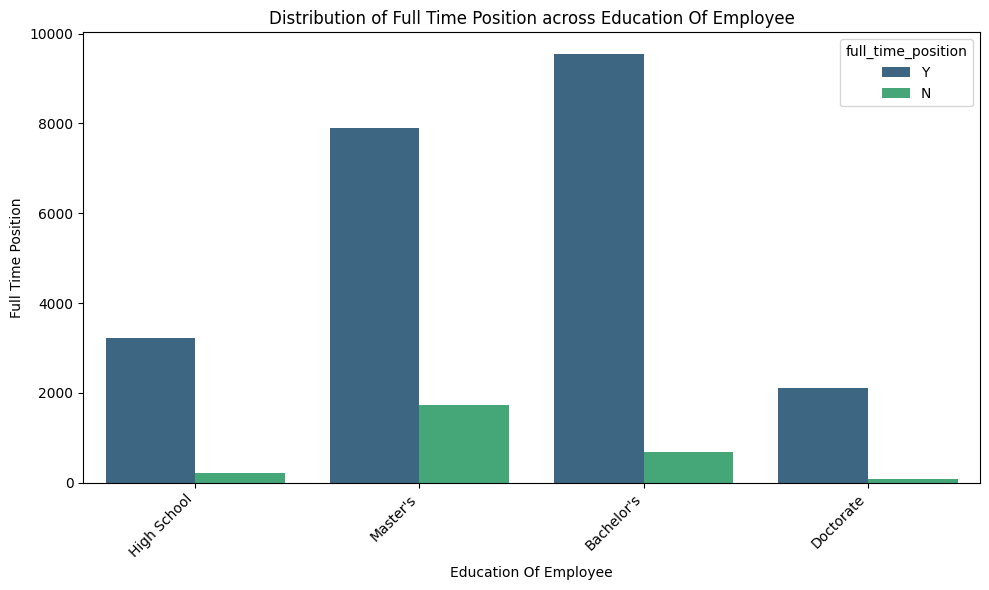

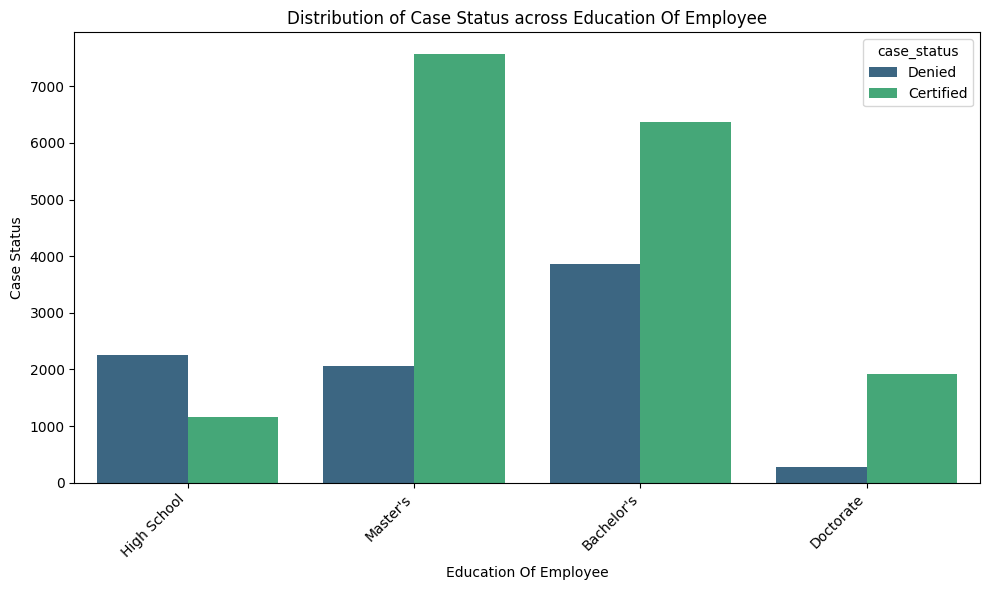

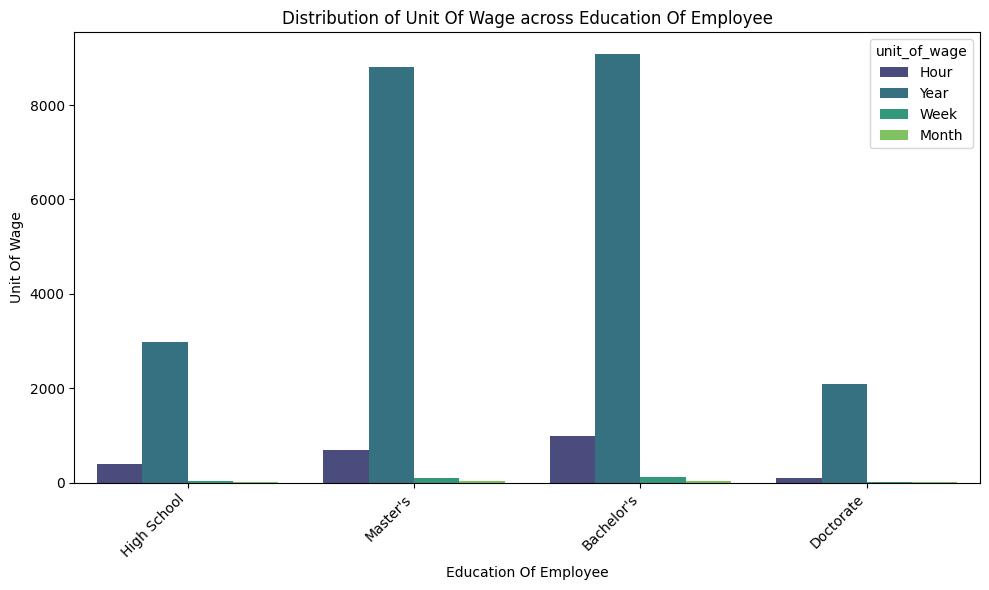

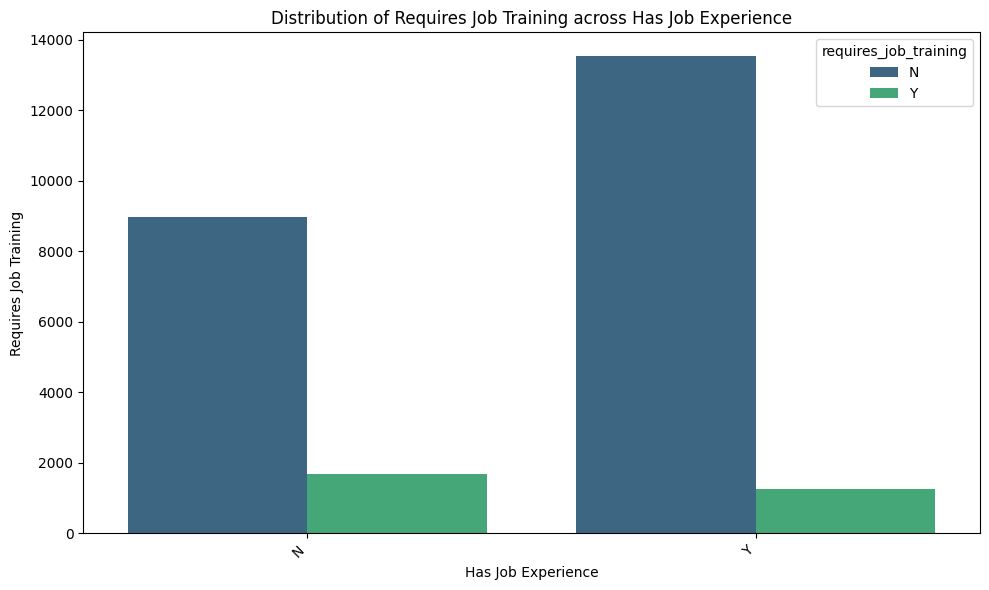

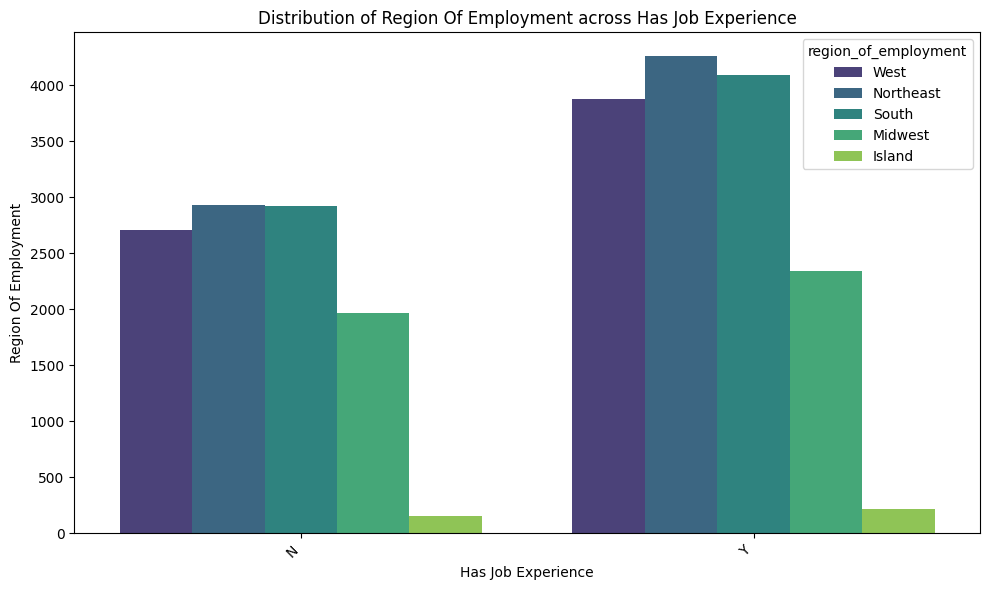

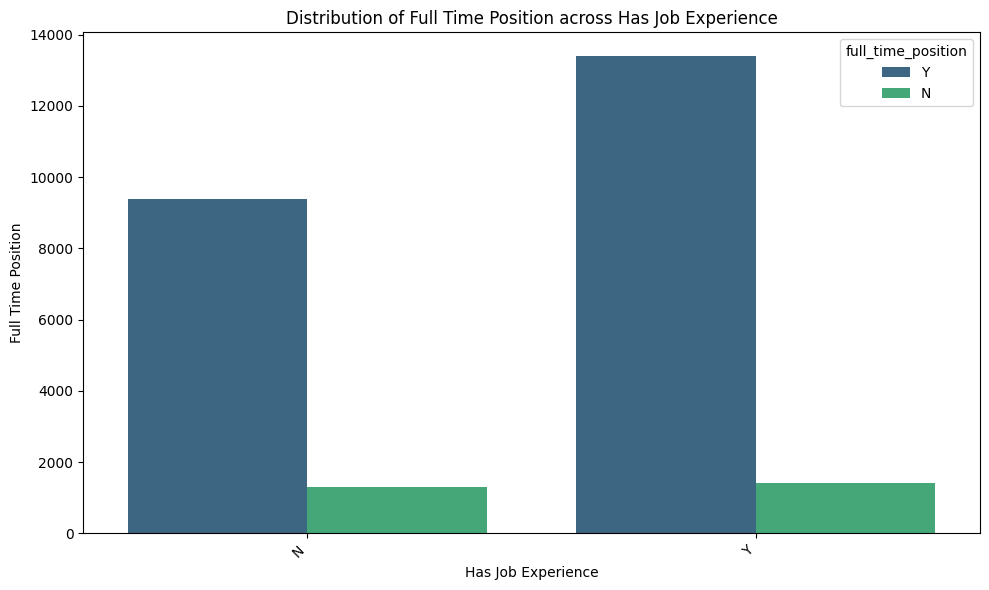

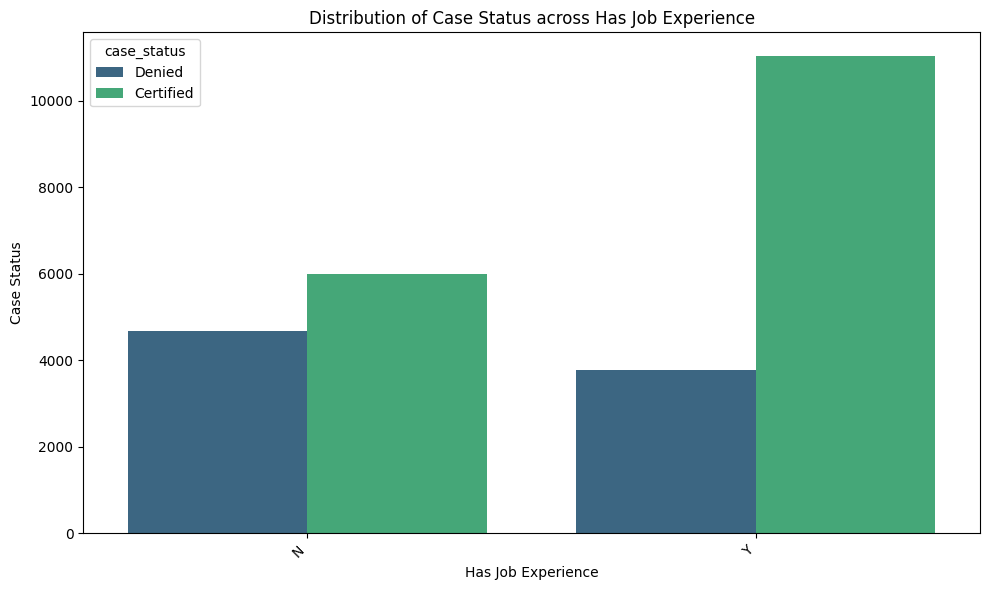

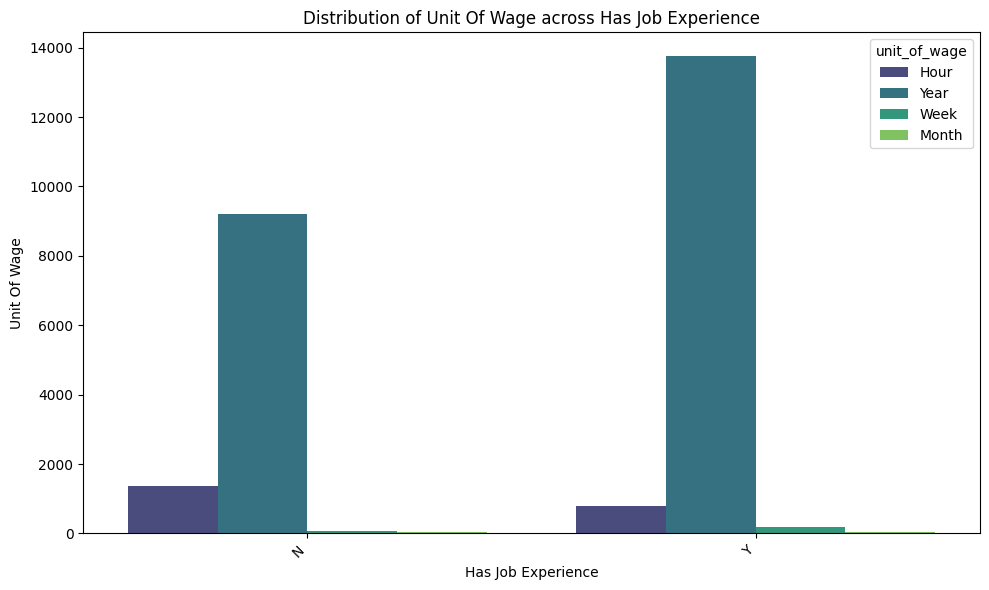

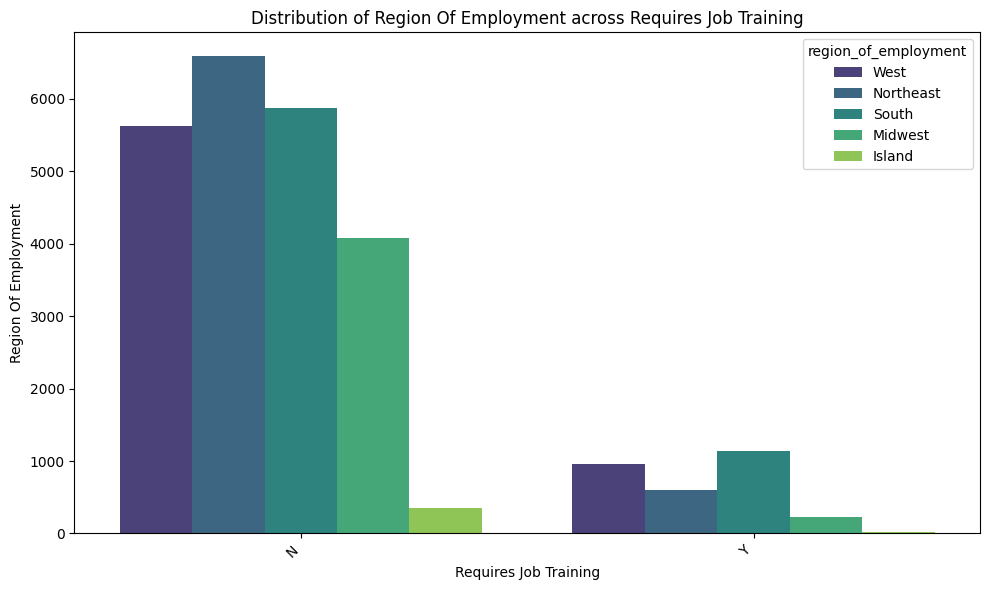

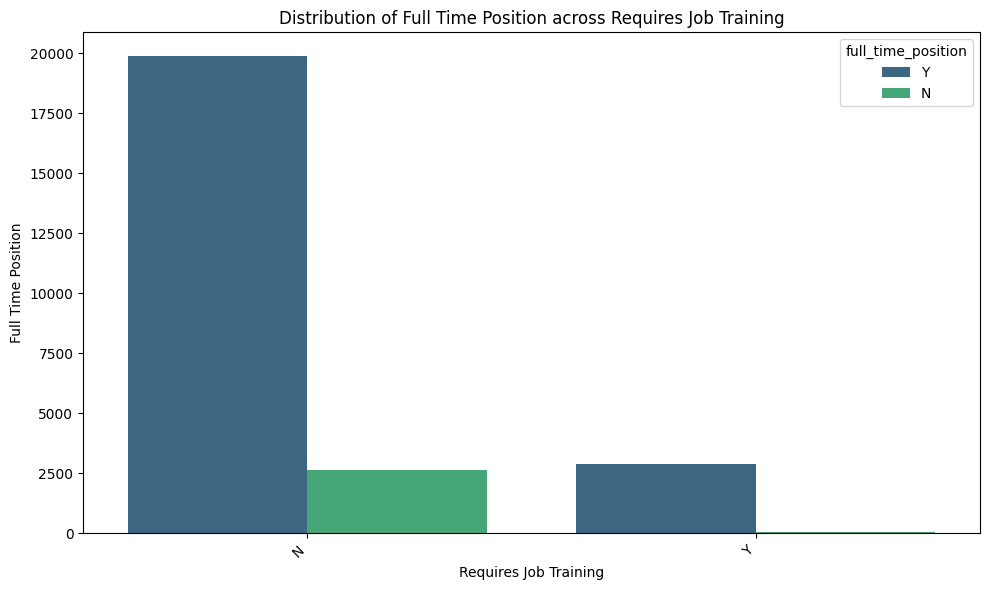

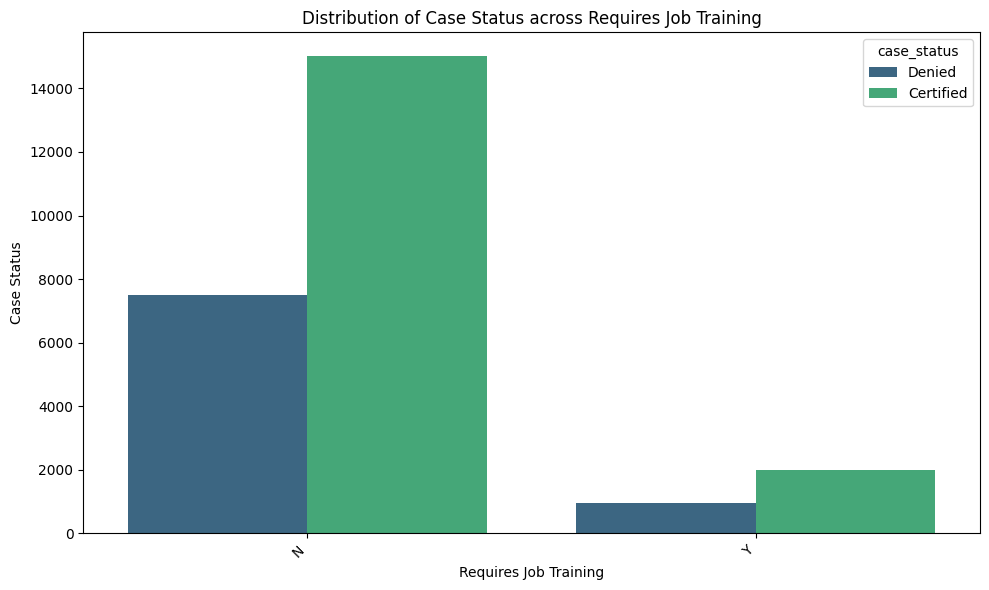

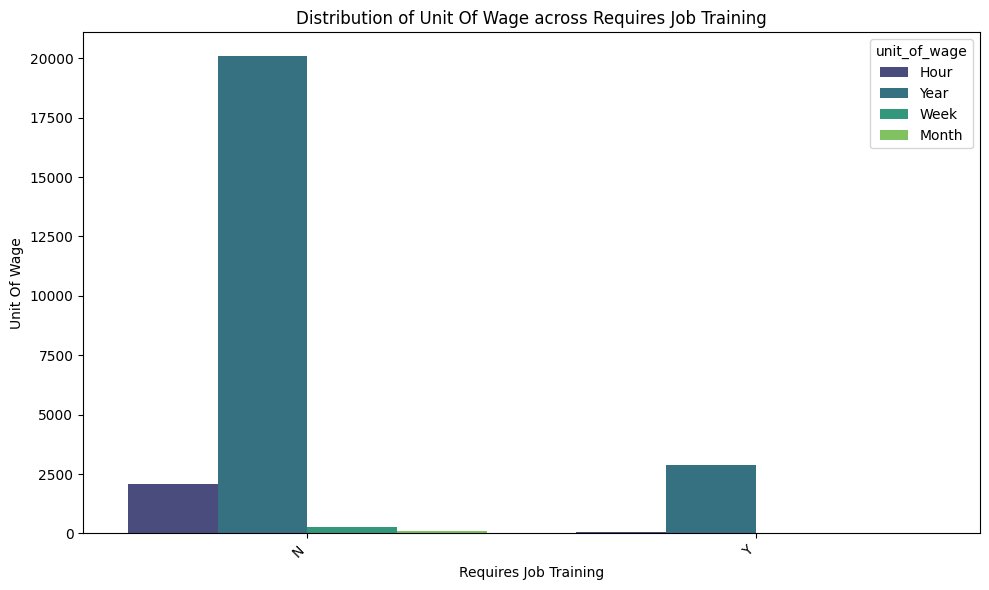

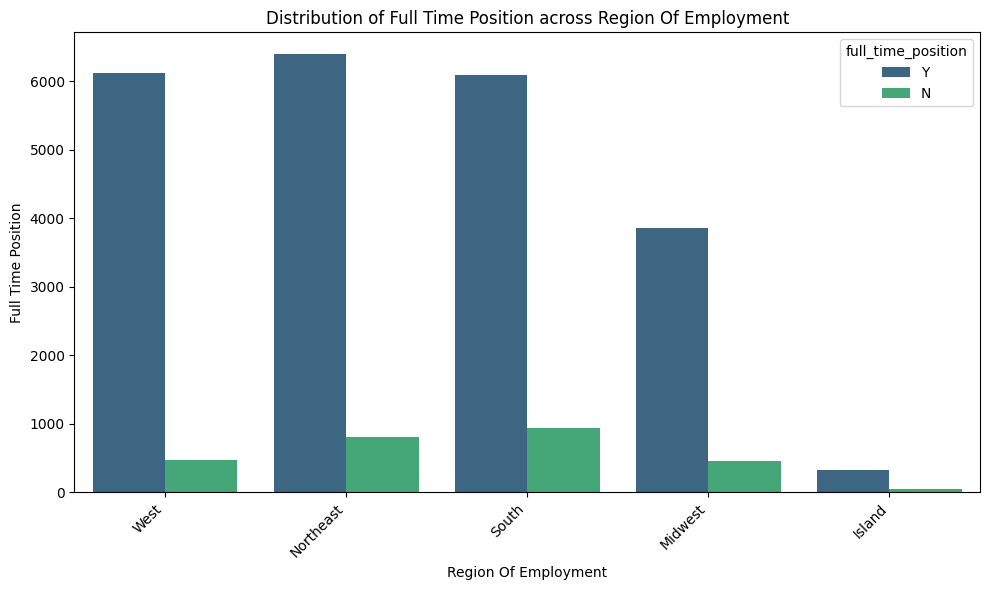

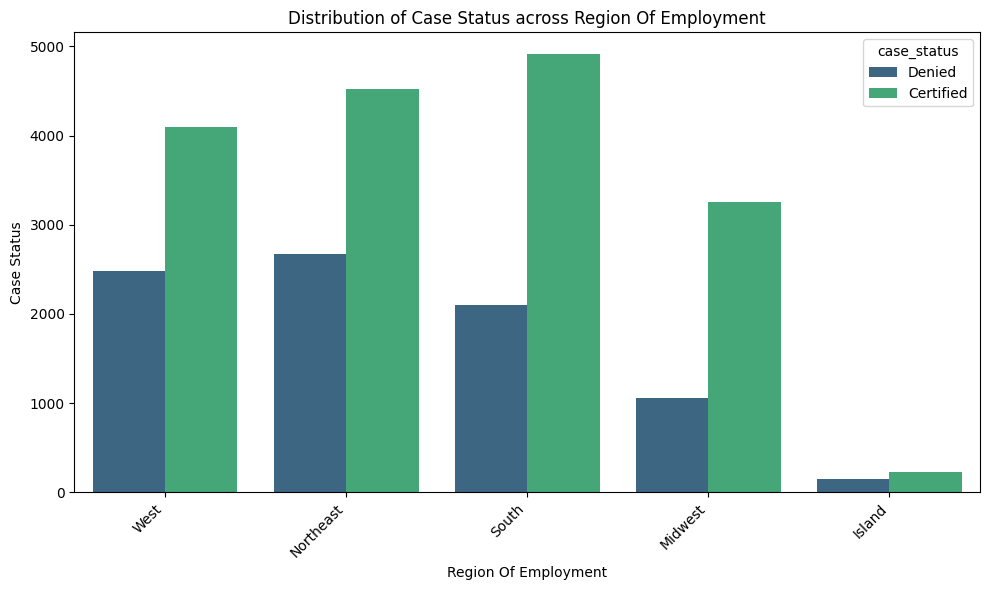

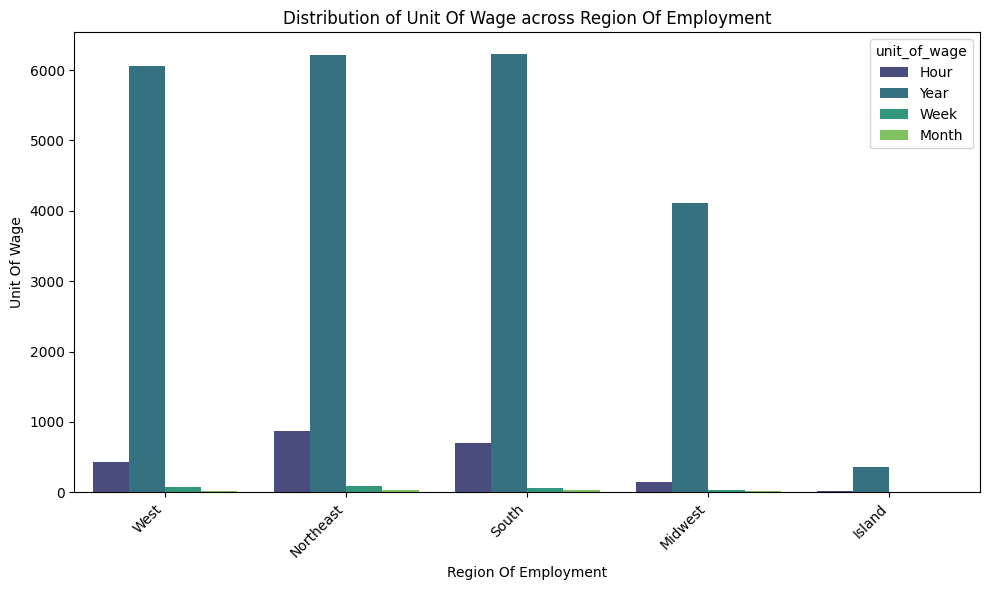

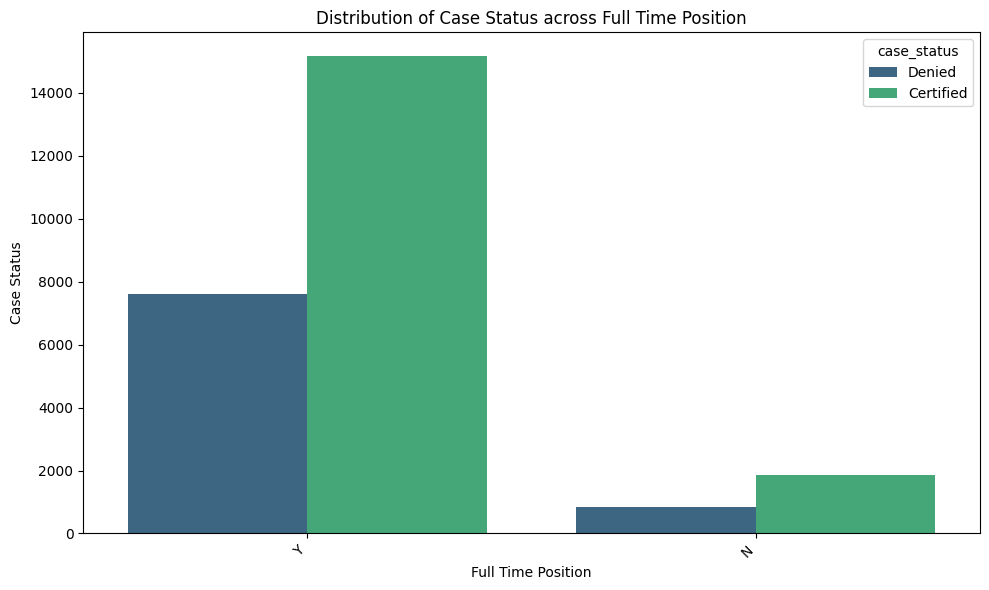

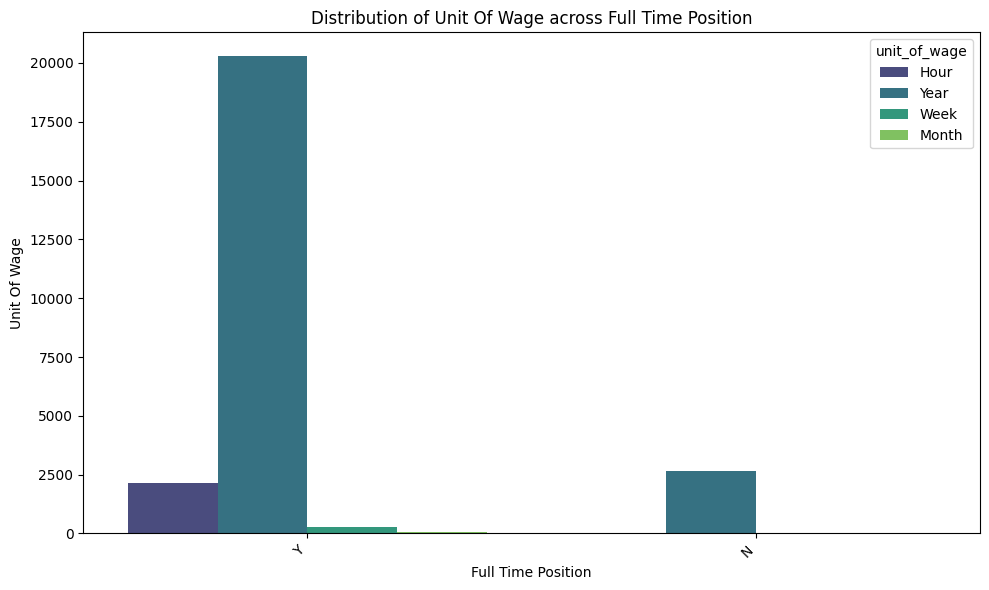

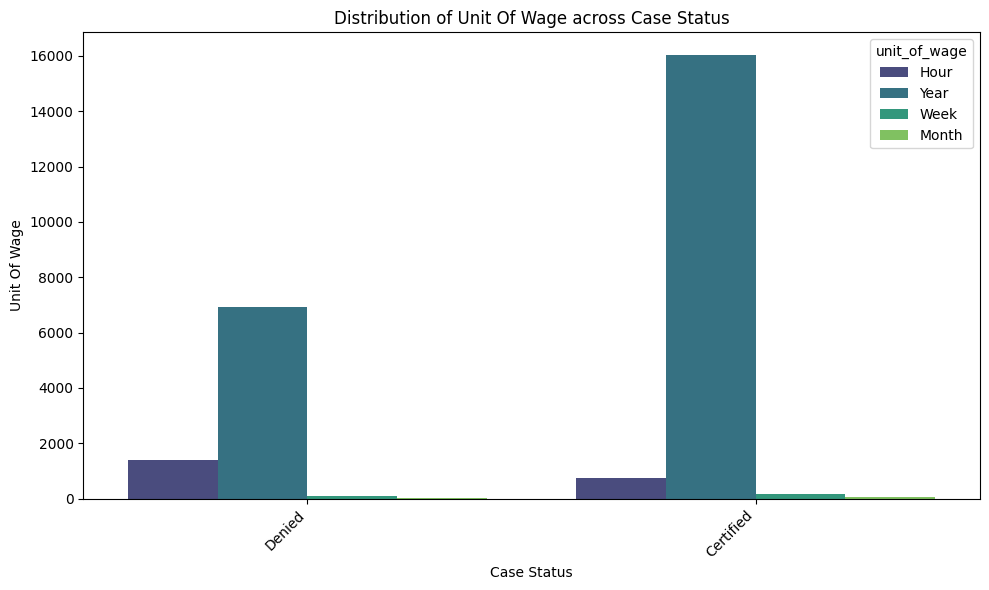

In [ ]:
for i, varx in enumerate(categorical_columns):
  for j, vary in enumerate(categorical_columns):
    if j > i:
      plt.figure(figsize=(10, 6))

      sns.countplot(data=df, x=varx, hue=vary, palette='viridis')
      plt.title(f"Distribution of {vary.replace('_', ' ').title()} across {varx.replace('_', ' ').title()}")
      plt.xlabel(varx.replace('_', ' ').title())
      plt.ylabel(vary.replace('_', ' ').title())
      plt.xticks(rotation=45, ha='right')
      plt.tight_layout()
      plt.show()

Observations of uneven distributions:
- Europe has a unusually high certified rate, followed by Asia and Africa
- Education of Employee with Bachelor's, Master's, and Doctorate have much higher certification rate for case status.
- Y for Has Job Exerpience has much higher certification rate for case status.
- South and Midwest are the two regions with highest levels of certification for case status.
-  Unit Of Wage with Year seems to have highest percentage of certification for case status.

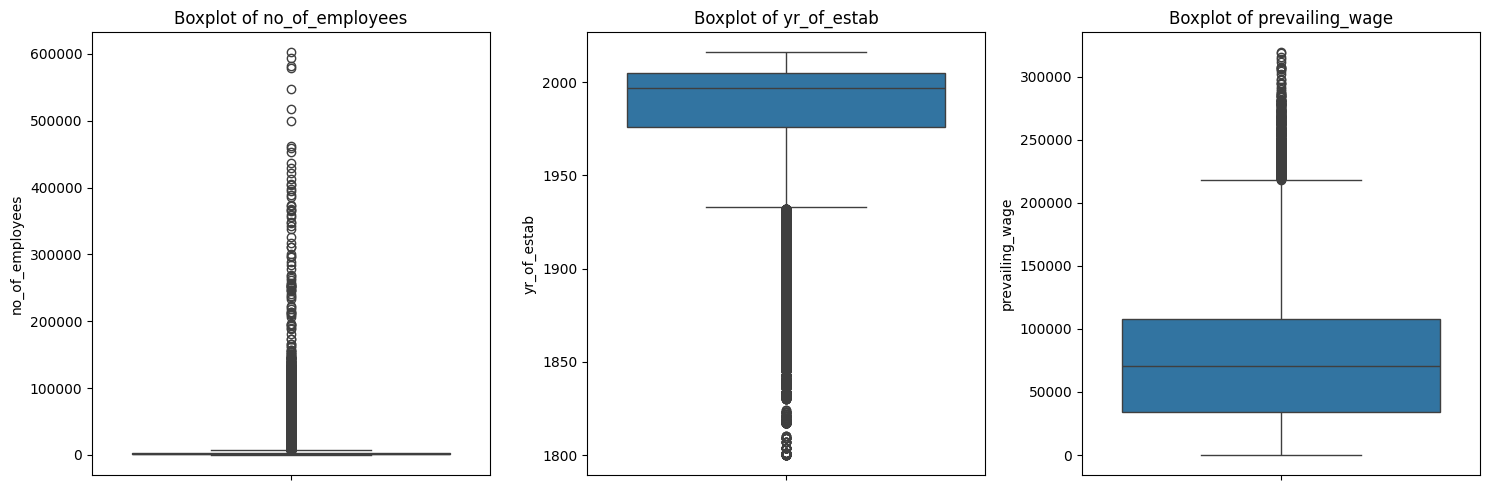

In [ ]:
# lets see if any outliers in quanitiative data
plt.figure(figsize=(15, 5))

for i, col in enumerate(quantitative_columns):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Observations:
- no_of_employees is heavily skewed to the right.
- yr_of_estab is skewed to the left.
- prevailing_wage is skewed to the right.

Additional Notes:
- All quanitivate categories are skewed.
- no_if_employess may have a few extreme outliers.

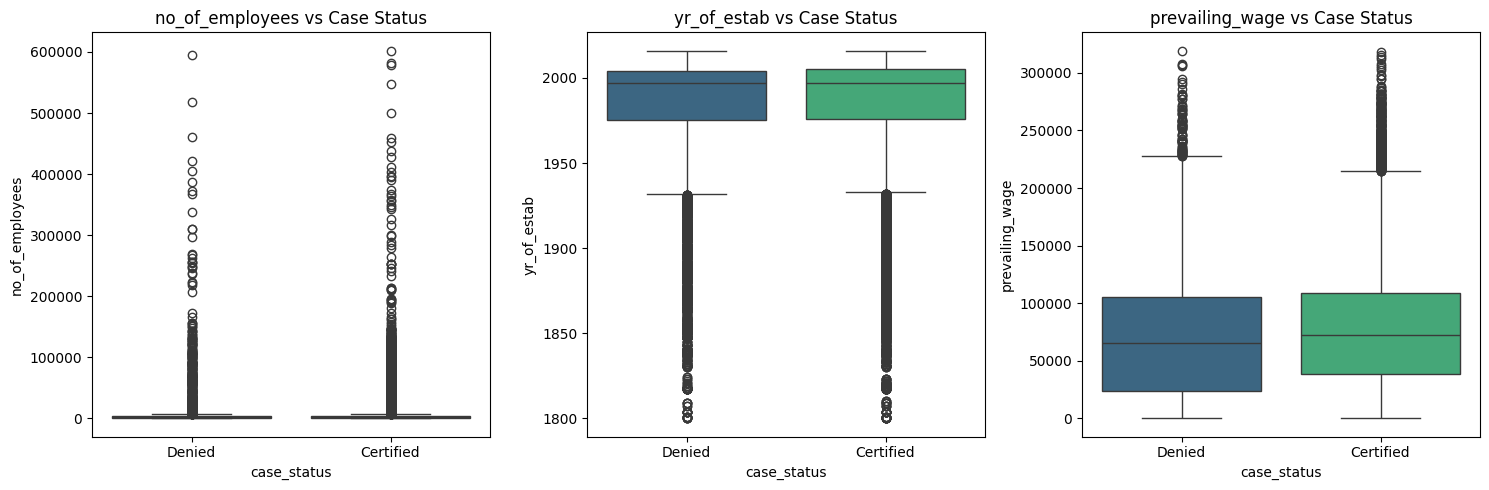

In [ ]:
# check for relationship between quantitative categories and case_status
plt.figure(figsize=(15, 5))

for i, col in enumerate(quantitative_columns):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x='case_status', y=col, hue='case_status', palette='viridis', legend=False)
    plt.title(f'{col} vs Case Status')

plt.tight_layout()
plt.show()

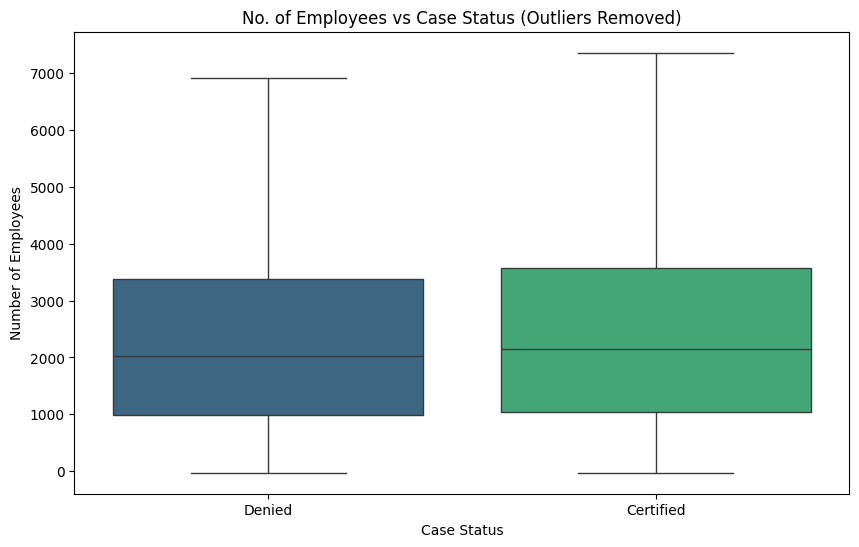

In [ ]:
# remove outliers to more clearly look at no_of_employess vs case_status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='case_status', y='no_of_employees', hue='case_status', palette='viridis', showfliers=False, legend=False)
plt.title('No. of Employees vs Case Status (Outliers Removed)')
plt.xlabel('Case Status')
plt.ylabel('Number of Employees')
plt.show()

There seems to be no large difference in quantitivate charactersitics between denied and certified case statuses

# **Data Pre-processing**

- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing data for modeling
- Any other preprocessing steps (check if needed)

In [ ]:
# split our data into X and Y for pre-processing
X = df.drop('case_status', axis=1)
# drop case_id
X = X.drop('case_id', axis=1)
y = df['case_status']
y = y.map({'Denied': 0, 'Certified': 1})

In [ ]:
# must run above cell first

# grouping week, month, hour together to reduce dimensionality
X['unit_of_wage'] = X['unit_of_wage'].replace(['week', 'month', 'hour'], 'short')

# one-hot-encoding for X
X = pd.get_dummies(X, drop_first=True)

# normalize yr_of_estab for earliest year to start at 0
X['yr_of_estab'] = X['yr_of_estab'] - X['yr_of_estab'].min()

# log scale no_of_employees to reduce effect of outliers
X['no_of_employees'] = np.log(X['no_of_employees'])

# fix NaNs in X if any were introduced by log(no_of_employees) for negative values
X = X.fillna(0)

print(X.head())


# Initial split to get a hold-out test set
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)


   no_of_employees  yr_of_estab  prevailing_wage  continent_Asia  \
0         9.582800          207         592.2029            True   
1         7.788212          202       83425.6500            True   
2        10.701985          208      122996.8600            True   
3         4.584967           97       83434.0300            True   
4         6.986566          205      149907.3900           False   

   continent_Europe  continent_North America  continent_Oceania  \
0             False                    False              False   
1             False                    False              False   
2             False                    False              False   
3             False                    False              False   
4             False                    False              False   

   continent_South America  education_of_employee_Doctorate  \
0                    False                            False   
1                    False                            False   

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


COMMENTS
- No NAN values, so no need for missing value treatment.
- We will keep all outliers for now as our quantitative columns seem to not be heavily correlated with case status and we do not want to lose information before testing.

CHANGES
- We are grouping week, month, hour categories in unit_of_wage into category to reduce complexity
- We are converts categorical text data into numerical binary columns
- We are offseting yr_of_estab by its minimum value so the years start from 0 instead of 1800
- Apply a natural log to no_of_employees to 'squash' the range of large values and reduce the impact of extreme outliers in company size.

# **Model Building - Original Data**

In [ ]:
# Setup K-Fold cross validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

### XGBoost

In [ ]:
xgb_model_base = XGBClassifier(random_state=1, eval_metric='logloss')
results_xgb_base = cross_validate(
    xgb_model_base,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print("XGBoost original data")
print(f"Mean Acccuracy: {results_xgb_base['test_accuracy'].mean()}")
print(f"Mean Recall: {results_xgb_base['test_recall'].mean()}")
print(f"Mean Precision: {results_xgb_base['test_precision'].mean()}")
print(f"Mean F1 Score: {results_xgb_base['test_f1'].mean()}")

XGBoost original data
Mean Acccuracy: 0.7363621242986158
Mean Recall: 0.8560304727222293
Mean Precision: 0.7734616846057504
Mean F1 Score: 0.8126344789669708


#### Random Forest

In [ ]:
random_forsest_model_base = RandomForestClassifier(random_state=1)
results_rf_base = cross_validate(
    random_forsest_model_base,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print("Random Forest original data")
print(f"Mean Acccuracy: {results_rf_base['test_accuracy'].mean()}")
print(f"Mean Recall: {results_rf_base['test_recall'].mean()}")
print(f"Mean Precision: {results_rf_base['test_precision'].mean()}")
print(f"Mean F1 Score: {results_rf_base['test_f1'].mean()}")

Random Forest original data
Mean Acccuracy: 0.7277769834512908
Mean Recall: 0.8420739540685748
Mean Precision: 0.7713575881466523
Mean F1 Score: 0.8051485645004993


#### Random Bagging

In [ ]:
random_bagging_model_base = BaggingClassifier(random_state=1)
results_bagging_base = cross_validate(
    random_bagging_model_base,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print("Bagging Classifier original data")
print(f"Mean Acccuracy: {results_bagging_base['test_accuracy'].mean()}")
print(f"Mean Recall: {results_bagging_base['test_recall'].mean()}")
print(f"Mean Precision: {results_bagging_base['test_precision'].mean()}")
print(f"Mean F1 Score: {results_bagging_base['test_f1'].mean()}")

Bagging Classifier original data
Mean Acccuracy: 0.7052098430049802
Mean Recall: 0.7816212776945944
Mean Precision: 0.7780475009691958
Mean F1 Score: 0.7798075498762815


#### Decision Tre

In [ ]:
decision_tree_model_base = DecisionTreeClassifier(random_state=1)
results_dt_base = cross_validate(
    decision_tree_model_base,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print("Decision Tree original data")
print(f"Mean Acccuracy: {results_dt_base['test_accuracy'].mean()}")
print(f"Mean Recall: {results_dt_base['test_recall'].mean()}")
print(f"Mean Precision: {results_dt_base['test_precision'].mean()}")
print(f"Mean F1 Score: {results_dt_base['test_f1'].mean()}")

Decision Tree original data
Mean Acccuracy: 0.6621371883682681
Mean Recall: 0.7430581410754389
Mean Precision: 0.7491038268846589
Mean F1 Score: 0.7460387297946568


#### AdaBoost

In [ ]:
ada_boost_model_base = AdaBoostClassifier(random_state=1)
results_ada_base = cross_validate(
    ada_boost_model_base,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print("AdaBoost Classifier original data")
print(f"Mean Acccuracy: {results_ada_base['test_accuracy'].mean()}")
print(f"Mean Recall: {results_ada_base['test_recall'].mean()}")
print(f"Mean Precision: {results_ada_base['test_precision'].mean()}")
print(f"Mean F1 Score: {results_ada_base['test_f1'].mean()}")

AdaBoost Classifier original data
Mean Acccuracy: 0.7400903558414168
Mean Recall: 0.8876161460203893
Mean Precision: 0.7623240273204388
Mean F1 Score: 0.8201965495590638


# **Model Building - Oversampled Data**

#### XGBoost

In [ ]:
xgb_model_over = Pipeline([
    ('undersampler', SMOTE(random_state=1)),
    ('xgb', XGBClassifier(random_state=1, eval_metric='logloss'))
])

# cross_validate returns a dictionary with train/test scores for every metric
results_xgb_over = cross_validate(
    xgb_model_over,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_xgb_over['test_accuracy'].mean()}")
print(f"Mean Recall: {results_xgb_over['test_recall'].mean()}")
print(f"Mean Precision: {results_xgb_over['test_precision'].mean()}")
print(f"Mean F1 Score: {results_xgb_over['test_f1'].mean()}")

Mean Acccuracy: 0.7356750920636433
Mean Recall: 0.8436900078062537
Mean Precision: 0.7789432318588287
Mean F1 Score: 0.810007621514431


#### Random Forest

In [ ]:
# Random Forest Classifier with Oversampling
random_forest_model_over = Pipeline([
    ('oversampler', SMOTE(random_state=1)),
    ('rf', RandomForestClassifier(random_state=1))
])
results_rf_over = cross_validate(
    random_forest_model_over,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("Random Forest with Oversampling")
print(f"Mean Acccuracy: {results_rf_over['test_accuracy'].mean()}")
print(f"Mean Recall: {results_rf_over['test_recall'].mean()}")
print(f"Mean Precision: {results_rf_over['test_precision'].mean()}")
print(f"Mean F1 Score: {results_rf_over['test_f1'].mean()}")

Random Forest with Oversampling
Mean Acccuracy: 0.722429794175565
Mean Recall: 0.8195976365912279
Mean Precision: 0.777038614204638
Mean F1 Score: 0.7977386607360755


#### Bagging Classifier

In [ ]:
# Bagging Classifier with Oversampling
bagging_model_over = Pipeline([
    ('oversampler', SMOTE(random_state=1)),
    ('bagging', BaggingClassifier(random_state=1))
])
results_bagging_over = cross_validate(
    bagging_model_over,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("Bagging Classifier with Oversampling")
print(f"Mean Acccuracy: {results_bagging_over['test_accuracy'].mean()}")
print(f"Mean Recall: {results_bagging_over['test_recall'].mean()}")
print(f"Mean Precision: {results_bagging_over['test_precision'].mean()}")
print(f"Mean F1 Score: {results_bagging_over['test_f1'].mean()}")


Bagging Classifier with Oversampling
Mean Acccuracy: 0.6932396316924715
Mean Recall: 0.7527537079705547
Mean Precision: 0.7802328330334193
Mean F1 Score: 0.7661957562384736


#### Decision Tree

In [ ]:
# Decision Tree with Oversampling
decision_tree_model_over = Pipeline([
    ('oversampler', SMOTE(random_state=1)),
    ('dt', DecisionTreeClassifier(random_state=1))
])
results_dt_over = cross_validate(
    decision_tree_model_over,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("Decision Tree with Oversampling")
print(f"Mean Acccuracy: {results_dt_over['test_accuracy'].mean()}")
print(f"Mean Recall: {results_dt_over['test_recall'].mean()}")
print(f"Mean Precision: {results_dt_over['test_precision'].mean()}")
print(f"Mean F1 Score: {results_dt_over['test_f1'].mean()}")

Decision Tree with Oversampling
Mean Acccuracy: 0.6554653393230365
Mean Recall: 0.723666683486225
Mean Precision: 0.751353121086429
Mean F1 Score: 0.737205720458955


#### AdaBoost

In [ ]:
# AdaBoost Classifier with Oversampling
ada_boost_model_over = Pipeline([
    ('oversampler', SMOTE(random_state=1)),
    ('ada', AdaBoostClassifier(random_state=1))
])
results_ada_over = cross_validate(
    ada_boost_model_over,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("AdaBoost Classifier with Oversampling")
print(f"Mean Acccuracy: {results_ada_over['test_accuracy'].mean()}")
print(f"Mean Recall: {results_ada_over['test_recall'].mean()}")
print(f"Mean Precision: {results_ada_over['test_precision'].mean()}")
print(f"Mean F1 Score: {results_ada_over['test_f1'].mean()}")

AdaBoost Classifier with Oversampling
Mean Acccuracy: 0.7396490352664111
Mean Recall: 0.870501858741075
Mean Precision: 0.7698671992919295
Mean F1 Score: 0.8170398046606279


# **Model Building - Undersampled Data**

In [ ]:
xgb_model_under = Pipeline([
    ('undersampler', TomekLinks(n_jobs=-1)),
    ('xgb', XGBClassifier(random_state=1, eval_metric='logloss'))
])

# cross_validate returns a dictionary with train/test scores for every metric
results_under = cross_validate(
    xgb_model_under,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_under['test_accuracy'].mean()}")
print(f"Mean Recall: {results_under['test_recall'].mean()}")
print(f"Mean Precision: {results_under['test_precision'].mean()}")
print(f"Mean F1 Score: {results_under['test_f1'].mean()}")

Mean Acccuracy: 0.7284145387743253
Mean Recall: 0.8135741660219917
Mean Precision: 0.7870049436106112
Mean F1 Score: 0.800043325292061


#### Random Forest

In [ ]:
# Random Forest with Undersampling
random_forest_model_under = Pipeline([
    ('undersampler', TomekLinks(n_jobs=-1)),
    ('rf', RandomForestClassifier(random_state=1))
])
results_rf_under = cross_validate(
    random_forest_model_under,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("Random Forest with Undersampling")
print(f"Mean Acccuracy: {results_rf_under['test_accuracy'].mean()}")
print(f"Mean Recall: {results_rf_under['test_recall'].mean()}")
print(f"Mean Precision: {results_rf_under['test_precision'].mean()}")
print(f"Mean F1 Score: {results_rf_under['test_f1'].mean()}")


Random Forest with Undersampling
Mean Acccuracy: 0.7206635610908078
Mean Recall: 0.7993242045405793
Mean Precision: 0.7860728535150221
Mean F1 Score: 0.7926284312621283


#### Decision Tree

In [ ]:
# Decision Tree with Undersampling
decision_tree_model_under = Pipeline([
    ('undersampler', TomekLinks(n_jobs=-1)),
    ('dt', DecisionTreeClassifier(random_state=1))
])
results_dt_under = cross_validate(
    decision_tree_model_under,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("Decision Tree with Undersampling")
print(f"Mean Acccuracy: {results_dt_under['test_accuracy'].mean()}")
print(f"Mean Recall: {results_dt_under['test_recall'].mean()}")
print(f"Mean Precision: {results_dt_under['test_precision'].mean()}")
print(f"Mean F1 Score: {results_dt_under['test_f1'].mean()}")

Decision Tree with Undersampling
Mean Acccuracy: 0.6547293476918679
Mean Recall: 0.7040547187900279
Mean Precision: 0.7610538202143738
Mean F1 Score: 0.7314341665736162


#### Bagging Classifier

In [ ]:
# Bagging Classifier with Undersampling
bagging_model_under = Pipeline([
    ('undersampler', TomekLinks(n_jobs=-1)),
    ('bagging', BaggingClassifier(random_state=1))
])
results_bagging_under = cross_validate(
    bagging_model_under,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("Bagging Classifier with Undersampling")
print(f"Mean Acccuracy: {results_bagging_under['test_accuracy'].mean()}")
print(f"Mean Recall: {results_bagging_under['test_recall'].mean()}")
print(f"Mean Precision: {results_bagging_under['test_precision'].mean()}")
print(f"Mean F1 Score: {results_bagging_under['test_f1'].mean()}")

Bagging Classifier with Undersampling
Mean Acccuracy: 0.6930927173981332
Mean Recall: 0.7359330524017386
Mean Precision: 0.7901780716693567
Mean F1 Score: 0.762062249234488


#### AdaBoost

In [ ]:
# AdaBoost Classifier with Undersampling
ada_boost_model_under = Pipeline([
    ('undersampler', TomekLinks(n_jobs=-1)),
    ('ada', AdaBoostClassifier(random_state=1))
])
results_ada_under = cross_validate(
    ada_boost_model_under,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)
print("AdaBoost Classifier with Undersampling")
print(f"Mean Acccuracy: {results_ada_under['test_accuracy'].mean()}")
print(f"Mean Recall: {results_ada_under['test_recall'].mean()}")
print(f"Mean Precision: {results_ada_under['test_precision'].mean()}")
print(f"Mean F1 Score: {results_ada_under['test_f1'].mean()}")


AdaBoost Classifier with Undersampling
Mean Acccuracy: 0.7427884903536269
Mean Recall: 0.8583813073006146
Mean Precision: 0.7790164984609954
Mean F1 Score: 0.8167597225191878


# **Hyperparameter Tuning**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid = {
    'n_estimators':[150,200,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,3,5],
    'subsample':[0.8,0.9]
}
```


#### HPT Selection
Selections were Original XGBoost, Oversampled XGBoost, Original Adaboost, Oversampled Adaboost, and Undersampled Adaboost as they had a f1_score above 80%

Selections for the orignal bagging, random forest and decision tree were also made to see whether parameter tuning would have a significant improvement.

#### XGBoost

In [ ]:
# XGBoost Param grid
param_grid = {
    'n_estimators':[150,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,5],
    'subsample':[0.8,0.9]
}


acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_xgb = RandomizedSearchCV(xgb_model_base, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_xgb.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_xgb.best_params_)
print("Best model found: ", rs_obj_xgb.best_estimator_)

xgb_model_orig_hp = rs_obj_xgb.best_estimator_

results_hp = cross_validate(
    xgb_model_orig_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 250, 'learning_rate': 0.2, 'gamma': 0}
Best model found:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)
Mean Acccuracy: 0.70099

In [ ]:
param_grid = {
    'xgb__n_estimators':[150,250],
    'xgb__scale_pos_weight':[5,10],
    'xgb__learning_rate':[0.1,0.2],
    'xgb__gamma':[0,5],
    'xgb__subsample':[0.8,0.9]
}

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_xgb = RandomizedSearchCV(xgb_model_over, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_xgb.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_xgb.best_params_)
print("Best model found: ", rs_obj_xgb.best_estimator_)

xgb_model_over_hp = rs_obj_xgb.best_estimator_

results_hp = cross_validate(
    xgb_model_over_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'xgb__subsample': 0.8, 'xgb__scale_pos_weight': 5, 'xgb__n_estimators': 250, 'xgb__learning_rate': 0.2, 'xgb__gamma': 5}
Best model found:  Pipeline(steps=[('undersampler', SMOTE(random_state=1)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=5, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                             

#### Adaboost

In [ ]:
# Adaboost Param grid
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_ada = RandomizedSearchCV(ada_boost_model_base, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_ada.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_ada.best_params_)
print("Best model found: ", rs_obj_ada.best_estimator_)

ada_model_orig_hp = rs_obj_ada.best_estimator_

results_ada_hp = cross_validate(
    ada_model_orig_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_ada_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_ada_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_ada_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_ada_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'n_estimators': 150, 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best model found:  AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=150, random_state=1)
Mean Acccuracy: 0.749607614750691
Mean Recall: 0.8743939764754642
Mean Precision: 0.7781539813753111
Mean F1 Score: 0.8234638084491323


In [ ]:
# Adaboost Param grid
param_grid = {
    "ada__n_estimators": [100, 150, 200],
    "ada__learning_rate": [0.2, 0.05],
    "ada__estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_ada = RandomizedSearchCV(ada_boost_model_over, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_ada.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_ada.best_params_)
print("Best model found: ", rs_obj_ada.best_estimator_)

ada_model_over_hp = rs_obj_ada.best_estimator_

results_ada_hp = cross_validate(
    ada_model_over_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_ada_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_ada_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_ada_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_ada_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'ada__n_estimators': 100, 'ada__learning_rate': 0.05, 'ada__estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best model found:  Pipeline(steps=[('oversampler', SMOTE(random_state=1)),
                ('ada',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                     random_state=1),
                                    learning_rate=0.05, n_estimators=100,
                                    random_state=1))])
Mean Acccuracy: 0.7321433480091171
Mean Recall: 0.8871003882079966
Mean Precision: 0.7550144751816257
Mean F1 Score: 0.8156517510747385


In [ ]:
# Adaboost Param grid
param_grid = {
    "ada__n_estimators": [100, 150, 200],
    "ada__learning_rate": [0.2, 0.05],
    "ada__estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_ada = RandomizedSearchCV(ada_boost_model_under, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_ada.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_ada.best_params_)
print("Best model found: ", rs_obj_ada.best_estimator_)

ada_model_under_hp = rs_obj_ada.best_estimator_

results_ada_hp = cross_validate(
    ada_model_under_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_ada_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_ada_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_ada_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_ada_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'ada__n_estimators': 100, 'ada__learning_rate': 0.05, 'ada__estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best model found:  Pipeline(steps=[('undersampler', TomekLinks(n_jobs=-1)),
                ('ada',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                     random_state=1),
                                    learning_rate=0.05, n_estimators=100,
                                    random_state=1))])
Mean Acccuracy: 0.7475472642312616
Mean Recall: 0.8610253958240184
Mean Precision: 0.7827363090303596
Mean F1 Score: 0.8200070991317452


#### Bagging Classifier

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics

# Bagging Classifier Param grid
param_grid = {
    'max_samples': [0.8, 0.9, 1.0],
    'max_features': [0.7, 0.8, 0.9],
    'n_estimators': [30, 50, 70],
}

model = BaggingClassifier(random_state=1)

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_bc = RandomizedSearchCV(model, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_bc.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_bc.best_params_)
print("Best model found: ", rs_obj_bc.best_estimator_)

bagging_model_hp = rs_obj_bc.best_estimator_

results_bagging_hp = cross_validate(
    bagging_model_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_bagging_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_bagging_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_bagging_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_bagging_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'n_estimators': 70, 'max_samples': 0.8, 'max_features': 0.7}
Best model found:  BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70,
                  random_state=1)
Mean Acccuracy: 0.7275805922450146
Mean Recall: 0.8893050275458492
Mean Precision: 0.7495550550478716
Mean F1 Score: 0.8134533723653593


#### Random Forest

In [ ]:
# Random Forest Param grid
param_grid = {
    "n_estimators": [200, 300],
    "min_samples_leaf": [1,4],
    "max_features": [0.3, 0.6],
    "max_samples": [0.4, 0.7]
}

model = RandomForestClassifier(random_state=1)

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_rf = RandomizedSearchCV(model, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_rf.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_rf.best_params_)
print("Best model found: ", rs_obj_rf.best_estimator_)

rf_model_hp = rs_obj_rf.best_estimator_

results_rf_hp = cross_validate(
    rf_model_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_rf_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_rf_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_rf_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_rf_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'n_estimators': 200, 'min_samples_leaf': 4, 'max_samples': 0.4, 'max_features': 0.3}
Best model found:  RandomForestClassifier(max_features=0.3, max_samples=0.4, min_samples_leaf=4,
                       n_estimators=200, random_state=1)
Mean Acccuracy: 0.7510795739425288
Mean Recall: 0.8707211516018741
Mean Precision: 0.7815357665834959
Mean F1 Score: 0.8237129292812708


#### Decision Tree

In [ ]:
# Decision Tree Param grid
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

model = DecisionTreeClassifier(random_state=1)

acc_scorer = metrics.make_scorer(metrics.f1_score)
rs_obj_dt = RandomizedSearchCV(model, param_grid, n_iter=10, scoring=acc_scorer, cv=4, verbose=1, random_state=1)
rs_obj_dt.fit(X_train_full, y_train_full)

print("Best parameters found: ", rs_obj_dt.best_params_)
print("Best model found: ", rs_obj_dt.best_estimator_)

dt_model_hp = rs_obj_dt.best_estimator_

results_dt_hp = cross_validate(
    dt_model_hp,
    X_train_full,
    y_train_full,
    cv=kf,
    scoring=['accuracy', 'recall', 'precision', 'f1'],
    n_jobs=-1
)

print(f"Mean Acccuracy: {results_dt_hp['test_accuracy'].mean()}")
print(f"Mean Recall: {results_dt_hp['test_recall'].mean()}")
print(f"Mean Precision: {results_dt_hp['test_precision'].mean()}")
print(f"Mean F1 Score: {results_dt_hp['test_f1'].mean()}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best parameters found:  {'min_samples_leaf': 7, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': np.int64(5)}
Best model found:  DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, min_samples_leaf=7,
                       random_state=1)
Mean Acccuracy: 0.735479374831356
Mean Recall: 0.913838817723569
Mean Precision: 0.7467927843304855
Mean F1 Score: 0.8219054428553498


# **Model Comparison and Final Model Selection**

In [ ]:
# accuracy method
def evaluate(model, pred, target, show: bool):
  p = model.predict(pred)

  cm = confusion_matrix(target, p)

  # Plot a confusion matrix
  if show:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

  acc = round(accuracy_score(target, p), 5)
  recall = round(recall_score(target, p), 5)
  precision = round(precision_score(target, p), 5)
  f1 = round(f1_score(target, p), 5)

  scores = {"a": acc, "r": recall, "p": precision, "f1": f1}

  return scores

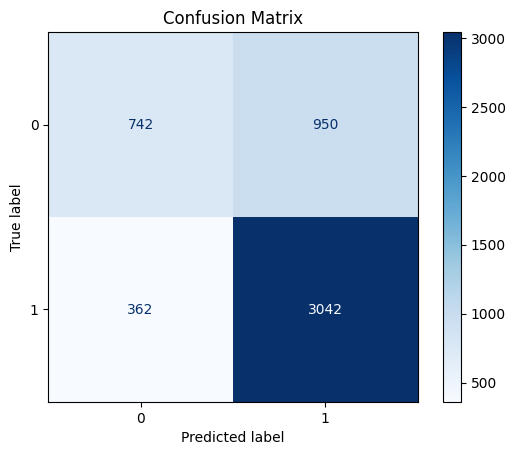

HP tuned Adaboost evalutation: {'a': 0.74254, 'r': 0.89365, 'p': 0.76202, 'f1': 0.82261}


In [ ]:
# The top three model is the hyperparameter tuned adaboost
ada_model_orig_hp.fit(X_test, y_test)

print(f"HP tuned Adaboost evalutation: {evaluate(ada_model_orig_hp, X_test, y_test, True)}")

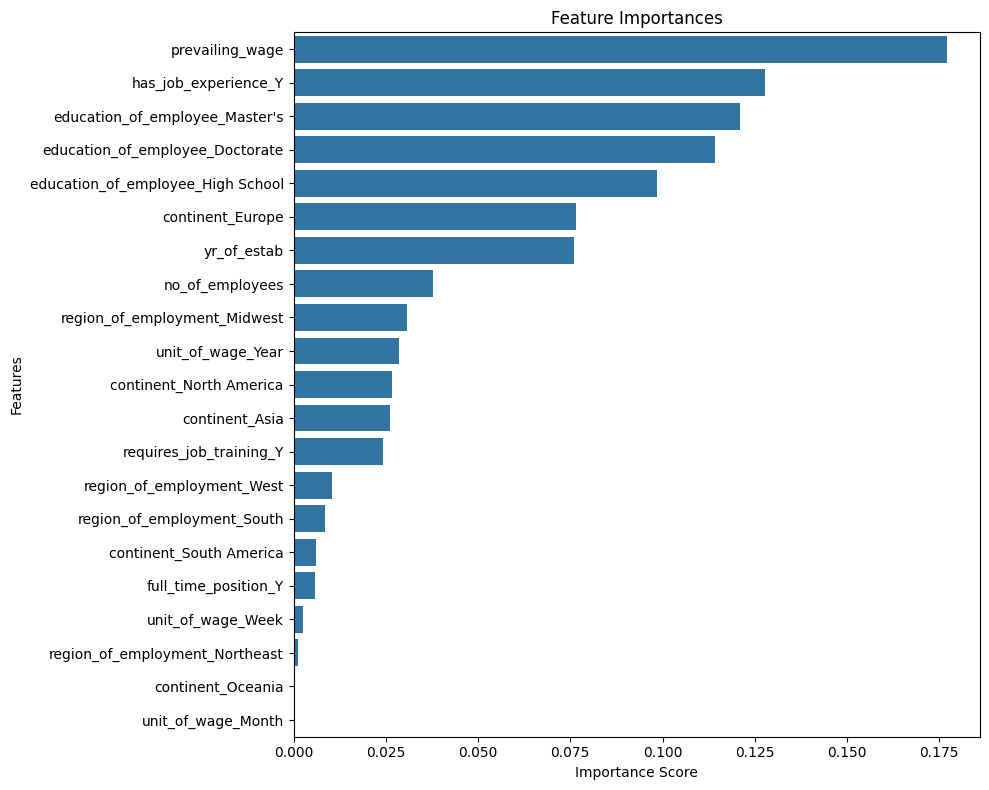

In [ ]:


feature_names = X_train_full.columns
importances = ada_model_orig_hp.feature_importances_

# Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
# Sort in descending order to put the most important features at the top
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)

plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# **Actionable Insights and Recommendations**

Actionable Insights
* Prevailing Wage is the most important factor in determining case status.
* It is also important that employees have job experience
* Education of Employee is the also a very important charactersitc (most likely negative correlation for highschool, positive for rest)
* Suprisingly, coming from Europe is seen as an important factor, however this is most likley due to Europe having the highest proportion of higher education and job experience applicants.
* Unit of Wage (being in years), Number of Employees, and Region of Employment (being in the Midwest) all had somewhat of an importance, signifying that while they might be correlated with Visa Case Status, they might not be a causation.

Recommendations
* For every case application, check education and job experience as they are the two most important factors
* The final model had a roughly 82-83% f_1 score.
* However because the model struggles with precision more than recall, make sure to check over VISA accept statuses.
* The final model is extremely well at predicting correct visa applications, however it has a relatively large error in predicting declines as accepts. (Therefore make sure to double check Visa acceptions)



In [ ]:
#nb covert
!jupyter nbconvert --execute --to html "/content/EasyVisaNotebook_(2) (3).ipynb"

[NbConvertApp] Converting notebook /content/EasyVisaNotebook_(2) (3).ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] 

___